# Osteoporosis Classification using Deep Learning

In [1]:
import warnings
warnings.filterwarnings("ignore")

## Making of csv File

In [2]:
import os
import pandas as pd

data_path = "/kaggle/input/multi-class-knee-osteoporosis-x-ray-dataset/OS Collected Data"

images = []
labels = []

for subfolder in os.listdir(data_path):

    subfolder_path = os.path.join(data_path, subfolder)
    if not os.path.isdir(subfolder_path):
        continue

    for image_filename in os.listdir(subfolder_path):
        image_path = os.path.join(subfolder_path, image_filename)
        images.append(image_path)

        labels.append(subfolder)

data = pd.DataFrame({'image': images, 'label': labels})

In [3]:
data.to_csv("/kaggle/working/Osteoporosis.csv")

In [4]:
df = pd.read_csv("/kaggle/working/Osteoporosis.csv")
df

,Unnamed: 0,image,label
0,0,/kaggle/input/multi-class-knee-osteoporosis-x-...,Osteopenia
1,1,/kaggle/input/multi-class-knee-osteoporosis-x-...,Osteopenia
2,2,/kaggle/input/multi-class-knee-osteoporosis-x-...,Osteopenia
3,3,/kaggle/input/multi-class-knee-osteoporosis-x-...,Osteopenia
4,4,/kaggle/input/multi-class-knee-osteoporosis-x-...,Osteopenia
...,...,...,...
1942,1942,/kaggle/input/multi-class-knee-osteoporosis-x-...,Normal
1943,1943,/kaggle/input/multi-class-knee-osteoporosis-x-...,Normal
1944,1944,/kaggle/input/multi-class-knee-osteoporosis-x-...,Normal
1945,1945,/kaggle/input/multi-class-knee-osteoporosis-x-...,Normal


In [5]:
df['label'].value_counts()

label
Osteoporosis    793
Normal          780
Osteopenia      374
Name: count, dtype: int64

## Ensemble Learning

### 1. VGG 16 + VGG 19

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/100


2025-04-20 10:58:14.437018: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng36{k2=3,k3=0} for conv (f32[64,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,64,224,224]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-04-20 10:58:14.564567: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.127663941s
Trying algorithm eng36{k2=3,k3=0} for conv (f32[64,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,64,224,224]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationF

24/24 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step - accuracy: 0.5037 - loss: 1.1114 - val_accuracy: 0.3490 - val_loss: 1.0651 - learning_rate: 0.0010
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.6742 - loss: 0.7945 - val_accuracy: 0.6963 - val_loss: 0.9891 - learning_rate: 0.0010
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.7014 - loss: 0.7241 - val_accuracy: 0.6840 - val_loss: 0.9565 - learning_rate: 0.0010
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.6874 - loss: 0.7235 - val_accuracy: 0.6534 - val_loss: 0.9330 - learning_rate: 0.0010
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.6916 - loss: 0.7175 - val_accuracy: 0.6442 - val_loss: 0.9031 - learning_rate: 0.0010
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.7108 - loss: 0.6490 - val_accuracy: 0.6442 - val_loss: 0.9060 - learning_rate: 0.0010
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.7270 - loss: 0.6544 - val_accuracy: 0.66

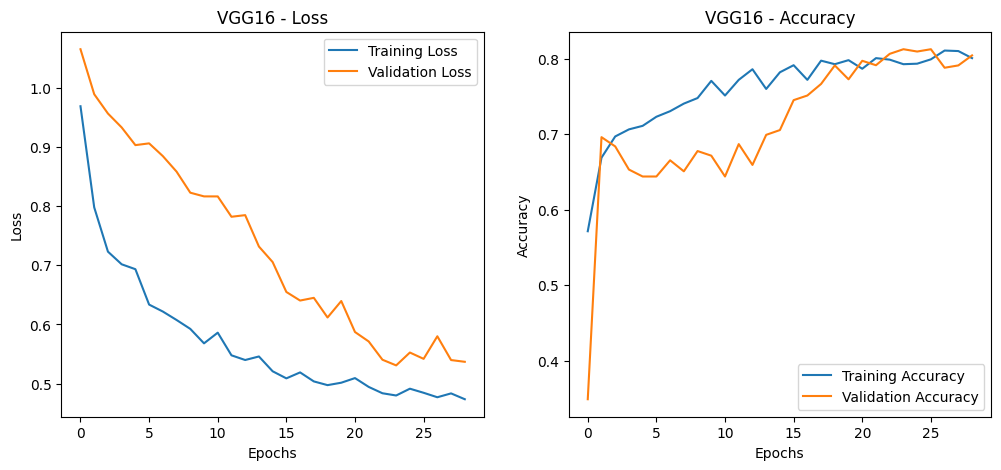

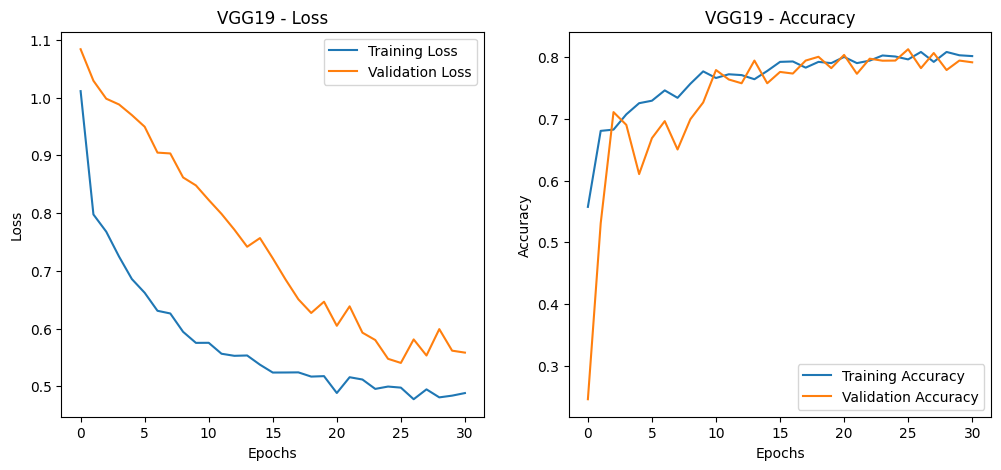

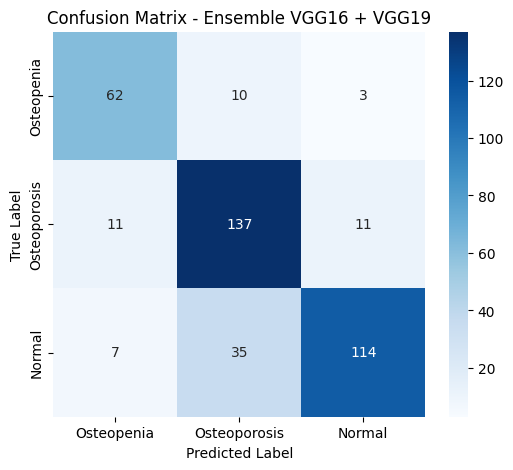

Classification Report (Ensemble):
              precision    recall  f1-score   support

  Osteopenia       0.78      0.83      0.80        75
Osteoporosis       0.75      0.86      0.80       159
      Normal       0.89      0.73      0.80       156

    accuracy                           0.80       390
   macro avg       0.81      0.81      0.80       390
weighted avg       0.81      0.80      0.80       390



In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

# Load CSV file
csv_path = "/kaggle/working/Osteoporosis.csv"
df = pd.read_csv(csv_path)

# Encode labels
label_mapping = {label: idx for idx, label in enumerate(df['label'].unique())}
df['label'] = df['label'].map(label_mapping)

# Load and preprocess images (duplicate grayscale channel to 3 channels)
def load_image(image_path, target_size=(224, 224)):
    img = Image.open(image_path).convert('L').resize(target_size)
    img = img_to_array(img) / 255.0
    img = np.repeat(img, 3, axis=-1)  # Convert (H, W, 1) to (H, W, 3)
    return img

image_paths = df['image'].values
labels = df['label'].values

# Split dataset
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)

# Data generator
def data_generator(image_paths, labels, batch_size=64):
    while True:
        for i in range(0, len(image_paths), batch_size):
            batch_paths = image_paths[i:i+batch_size]
            batch_labels = labels[i:i+batch_size]
            images = np.array([load_image(img_path) for img_path in batch_paths])
            yield images, tf.keras.utils.to_categorical(batch_labels, num_classes=3)

train_gen = data_generator(train_paths, train_labels)
val_gen = data_generator(val_paths, val_labels)

# Define a function to build VGG model
def build_vgg_model(base_model_class, input_shape=(224, 224, 3)):
    base_model = base_model_class(weights='imagenet', include_top=False, input_shape=input_shape)
    for layer in base_model.layers:
        layer.trainable = False
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    output = Dense(3, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Build and train VGG16 model
model_vgg16 = build_vgg_model(VGG16)
history_vgg16 = model_vgg16.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=len(train_paths) // 64,
    validation_steps=len(val_paths) // 64,
    epochs=100,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.LearningRateScheduler(lambda epoch, lr: lr * 0.9 if epoch > 10 else lr)
    ]
)
model_vgg16.save("/kaggle/working/VGG16_knee_osteo_model.keras")

# Build and train VGG19 model
model_vgg19 = build_vgg_model(VGG19)
history_vgg19 = model_vgg19.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=len(train_paths) // 64,
    validation_steps=len(val_paths) // 64,
    epochs=100,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.LearningRateScheduler(lambda epoch, lr: lr * 0.9 if epoch > 10 else lr)
    ]
)
model_vgg19.save("/kaggle/working/VGG19_knee_osteo_model.keras")

# Load validation data
val_images = np.array([load_image(img_path) for img_path in val_paths])
val_labels_cat = tf.keras.utils.to_categorical(val_labels, num_classes=3)

# Predictions
preds_vgg16 = model_vgg16.predict(val_images)
preds_vgg19 = model_vgg19.predict(val_images)
ensemble_preds = (preds_vgg16 + preds_vgg19) / 2
final_preds = np.argmax(ensemble_preds, axis=1)

# Plot training history
def plot_training_history(history, title):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'{title} - Loss')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f'{title} - Accuracy')
    plt.show()

plot_training_history(history_vgg16, 'VGG16')
plot_training_history(history_vgg19, 'VGG19')

# Confusion Matrix
cm = confusion_matrix(val_labels, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Ensemble VGG16 + VGG19')
plt.show()

# Classification Report
print("Classification Report (Ensemble):")
print(classification_report(val_labels, final_preds, target_names=label_mapping.keys()))

### 2. InceptionV3 + Xception

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 107s 4s/step - accuracy: 0.5948 - loss: 1.1557 - val_accuracy: 0.5307 - val_loss: 1.0945
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.7214 - loss: 0.7572 - val_accuracy: 0.6350 - val_loss: 0.9378
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.7371 - loss: 0.6476 - val_accuracy: 0.6406 - val_loss: 0.9107
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.7465 - loss: 0.6336 - val_accuracy: 0.6963 - val_loss: 0.7764
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.7929 - loss: 0.5200 - val_accuracy: 0.7699 - val_loss: 0.5985
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.7942 - loss: 0.4909 - val_accuracy: 0.7853 - val_loss: 0.6177
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.8215 - loss: 0.4594 - val_accuracy: 0.7791 - val_loss: 0.6948
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accura

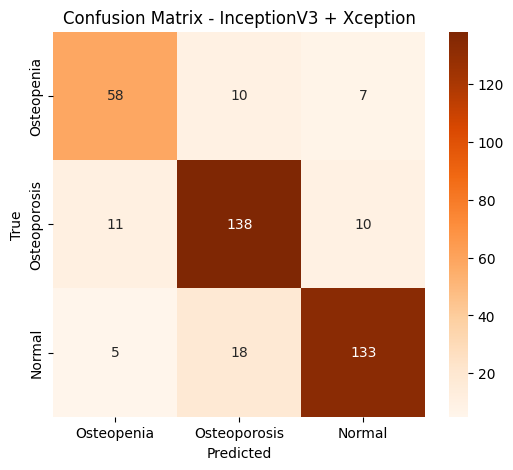

Classification Report (InceptionV3 + Xception):
              precision    recall  f1-score   support

  Osteopenia       0.78      0.77      0.78        75
Osteoporosis       0.83      0.87      0.85       159
      Normal       0.89      0.85      0.87       156

    accuracy                           0.84       390
   macro avg       0.83      0.83      0.83       390
weighted avg       0.84      0.84      0.84       390



In [ ]:
from tensorflow.keras.applications import InceptionV3, Xception

# Function to build Inception/Xception models
def build_model(base_model_class, input_shape=(224, 224, 3)):
    base_model = base_model_class(weights='imagenet', include_top=False, input_shape=input_shape)
    for layer in base_model.layers:
        layer.trainable = False
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    output = Dense(3, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Train InceptionV3
model_incep = build_model(InceptionV3)
history_incep = model_incep.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=len(train_paths) // 64,
    validation_steps=len(val_paths) // 64,
    epochs=100,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)
model_incep.save("/kaggle/working/InceptionV3_osteo_model.keras")

# Train Xception
model_xcep = build_model(Xception)
history_xcep = model_xcep.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=len(train_paths) // 64,
    validation_steps=len(val_paths) // 64,
    epochs=100,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)
model_xcep.save("/kaggle/working/Xception_osteo_model.keras")

# Predictions (Ensemble)
preds_incep = model_incep.predict(val_images)
preds_xcep = model_xcep.predict(val_images)
ensemble_preds_ix = (preds_incep + preds_xcep) / 2
final_preds_ix = np.argmax(ensemble_preds_ix, axis=1)

# Confusion Matrix and Report
cm_ix = confusion_matrix(val_labels, final_preds_ix)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ix, annot=True, fmt='d', cmap='Oranges', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - InceptionV3 + Xception')
plt.show()

print("Classification Report (InceptionV3 + Xception):")
print(classification_report(val_labels, final_preds_ix, target_names=label_mapping.keys()))


### 3. ResNet50 + DenseNet121

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 99s 3s/step - accuracy: 0.5733 - loss: 0.9653 - val_accuracy: 0.4049 - val_loss: 1.2943
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.6733 - loss: 0.8075 - val_accuracy: 0.4110 - val_loss: 1.1084
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.6968 - loss: 0.7385 - val_accuracy: 0.4089 - val_loss: 1.0352
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.6957 - loss: 0.7208 - val_accuracy: 0.6012 - val_loss: 0.9744
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.7353 - loss: 0.6836 - val_accuracy: 0.4080 - val_loss: 0.9826
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.7224 - loss: 0.6731 - val_accuracy: 0.4049 - val_loss: 1.0466
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.7482 - loss: 0.6662 - val_accuracy: 0.3865 - val_loss: 1.1114
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accurac

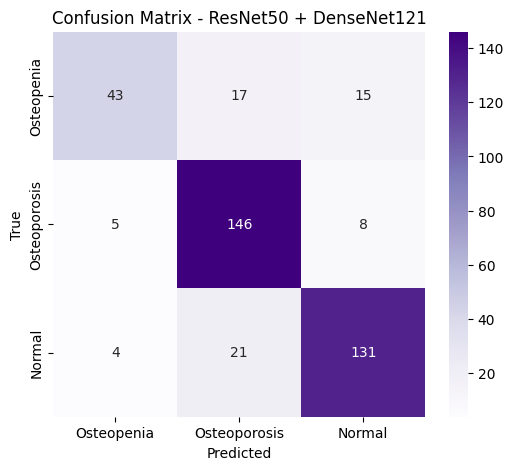

Classification Report (ResNet50 + DenseNet121):
              precision    recall  f1-score   support

  Osteopenia       0.83      0.57      0.68        75
Osteoporosis       0.79      0.92      0.85       159
      Normal       0.85      0.84      0.85       156

    accuracy                           0.82       390
   macro avg       0.82      0.78      0.79       390
weighted avg       0.82      0.82      0.82       390



In [ ]:
from tensorflow.keras.applications import ResNet50, DenseNet121

# Build ResNet50
model_resnet = build_model(ResNet50)
history_resnet = model_resnet.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=len(train_paths) // 64,
    validation_steps=len(val_paths) // 64,
    epochs=100,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)
model_resnet.save("/kaggle/working/ResNet50_osteo_model.keras")

# Build DenseNet121
model_dense = build_model(DenseNet121)
history_dense = model_dense.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=len(train_paths) // 64,
    validation_steps=len(val_paths) // 64,
    epochs=100,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)
model_dense.save("/kaggle/working/DenseNet121_osteo_model.keras")

# Predictions (Ensemble)
preds_resnet = model_resnet.predict(val_images)
preds_dense = model_dense.predict(val_images)
ensemble_preds_rd = (preds_resnet + preds_dense) / 2
final_preds_rd = np.argmax(ensemble_preds_rd, axis=1)

# Confusion Matrix and Report
cm_rd = confusion_matrix(val_labels, final_preds_rd)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rd, annot=True, fmt='d', cmap='Purples', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - ResNet50 + DenseNet121')
plt.show()

print("Classification Report (ResNet50 + DenseNet121):")
print(classification_report(val_labels, final_preds_rd, target_names=label_mapping.keys()))

### 4. AlexNet + MobileNetV2

I0000 00:00:1745158000.294393      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1745158000.295290      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50


I0000 00:00:1745158015.484605      62 service.cc:148] XLA service 0x7d51d0002630 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745158015.485683      62 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1745158015.485702      62 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1745158015.905031      62 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/24 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.3125 - loss: 1.1017

I0000 00:00:1745158024.411456      62 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


24/24 ━━━━━━━━━━━━━━━━━━━━ 112s 4s/step - accuracy: 0.4507 - loss: 1.0247 - val_accuracy: 0.5208 - val_loss: 0.9083
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.6202 - loss: 0.8118 - val_accuracy: 0.6534 - val_loss: 0.8012
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.6513 - loss: 0.7656 - val_accuracy: 0.6626 - val_loss: 0.7855
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.6877 - loss: 0.7155 - val_accuracy: 0.6626 - val_loss: 0.7397
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.6749 - loss: 0.6853 - val_accuracy: 0.7485 - val_loss: 0.6682
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.7070 - loss: 0.6488 - val_accuracy: 0.7025 - val_loss: 0.7464
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.7268 - loss: 0.6391 - val_accuracy: 0.7546 - val_loss: 0.6782
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.7585 - loss: 0.5885 - val_accuracy: 0.7604 - val_loss: 0.6588
Ep

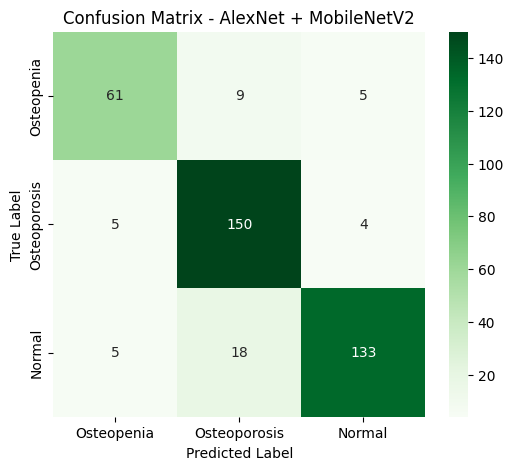

Classification Report (Ensemble: AlexNet + MobileNetV2):
              precision    recall  f1-score   support

  Osteopenia       0.86      0.81      0.84        75
Osteoporosis       0.85      0.94      0.89       159
      Normal       0.94      0.85      0.89       156

    accuracy                           0.88       390
   macro avg       0.88      0.87      0.87       390
weighted avg       0.89      0.88      0.88       390



In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- AlexNet-like model ---
def create_alexnet(input_shape=(224, 224, 3), num_classes=3):
    model = Sequential([
        Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=input_shape),
        MaxPooling2D((3, 3), strides=(2, 2)),
        Conv2D(256, (5, 5), padding="same", activation='relu'),
        MaxPooling2D((3, 3), strides=(2, 2)),
        Conv2D(384, (3, 3), padding="same", activation='relu'),
        Conv2D(384, (3, 3), padding="same", activation='relu'),
        Conv2D(256, (3, 3), padding="same", activation='relu'),
        MaxPooling2D((3, 3), strides=(2, 2)),
        Flatten(),
        Dense(4096, activation='relu'),
        Dropout(0.5),
        Dense(4096, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# --- MobileNetV2 model ---
def create_mobilenet(input_shape=(224, 224, 3), num_classes=3):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Train both models
alexnet = create_alexnet()
mobilenet = create_mobilenet()

history_alexnet = alexnet.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=len(train_paths) // 64,
    validation_steps=len(val_paths) // 64,
    epochs=50,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

history_mobilenet = mobilenet.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=len(train_paths) // 64,
    validation_steps=len(val_paths) // 64,
    epochs=50,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

# Load validation images
val_images = np.array([load_image(p) for p in val_paths])

# Ensemble prediction
preds_alexnet = alexnet.predict(val_images)
preds_mobilenet = mobilenet.predict(val_images)
ensemble_preds = (preds_alexnet + preds_mobilenet) / 2
final_preds = np.argmax(ensemble_preds, axis=1)

# Evaluation
cm = confusion_matrix(val_labels, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - AlexNet + MobileNetV2')
plt.show()

print("Classification Report (Ensemble: AlexNet + MobileNetV2):")
print(classification_report(val_labels, final_preds, target_names=label_mapping.keys()))

### 5. InceptionV3 + DenseNet121
### 6. Xception + DenseNet121
### 7. MobileNetV2 + Xception
### 8. InceptionV3 + MobileNetV2


Training Ensemble: InceptionV3 + DenseNet121
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 601ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step


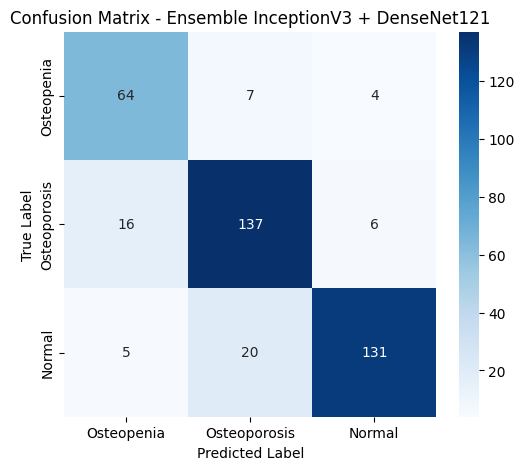

Classification Report for Ensemble: InceptionV3 + DenseNet121
              precision    recall  f1-score   support

  Osteopenia       0.75      0.85      0.80        75
Osteoporosis       0.84      0.86      0.85       159
      Normal       0.93      0.84      0.88       156

    accuracy                           0.85       390
   macro avg       0.84      0.85      0.84       390
weighted avg       0.86      0.85      0.85       390


Training Ensemble: Xception + DenseNet121
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 380ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 901ms/step


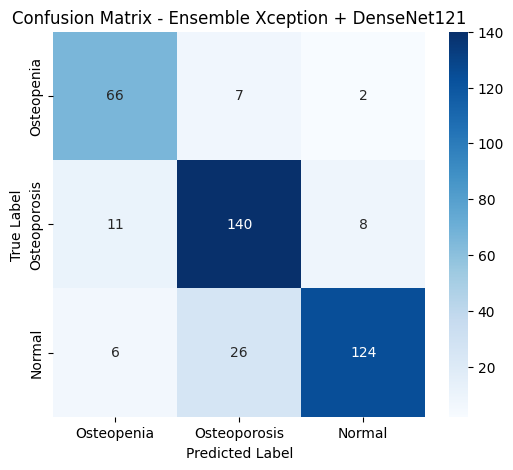

Classification Report for Ensemble: Xception + DenseNet121
              precision    recall  f1-score   support

  Osteopenia       0.80      0.88      0.84        75
Osteoporosis       0.81      0.88      0.84       159
      Normal       0.93      0.79      0.86       156

    accuracy                           0.85       390
   macro avg       0.84      0.85      0.84       390
weighted avg       0.85      0.85      0.85       390


Training Ensemble: MobileNetV2 + Xception
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 284ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 383ms/step


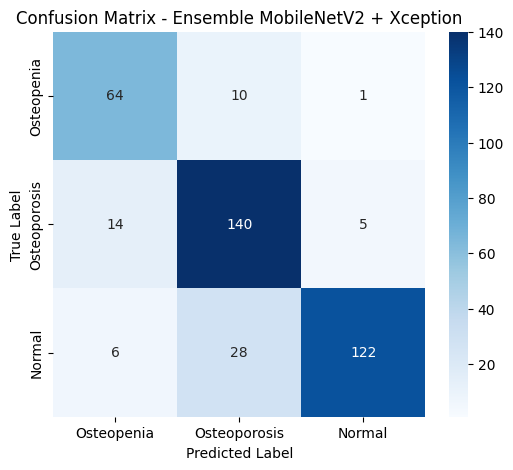

Classification Report for Ensemble: MobileNetV2 + Xception
              precision    recall  f1-score   support

  Osteopenia       0.76      0.85      0.81        75
Osteoporosis       0.79      0.88      0.83       159
      Normal       0.95      0.78      0.86       156

    accuracy                           0.84       390
   macro avg       0.83      0.84      0.83       390
weighted avg       0.85      0.84      0.84       390


Training Ensemble: InceptionV3 + MobileNetV2
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 507ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 268ms/step


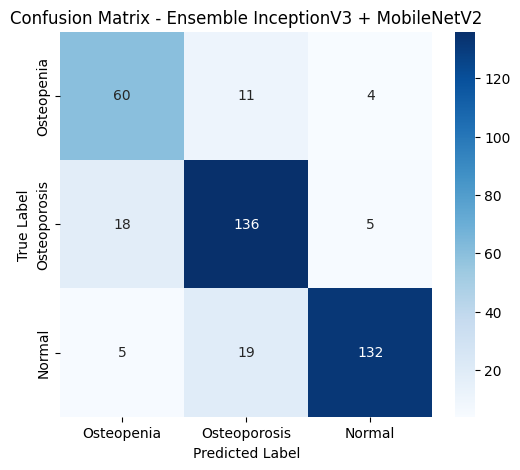

Classification Report for Ensemble: InceptionV3 + MobileNetV2
              precision    recall  f1-score   support

  Osteopenia       0.72      0.80      0.76        75
Osteoporosis       0.82      0.86      0.84       159
      Normal       0.94      0.85      0.89       156

    accuracy                           0.84       390
   macro avg       0.83      0.83      0.83       390
weighted avg       0.85      0.84      0.84       390



In [ ]:
# Ensemble Learning Code for 4 Model Pairs

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3, DenseNet121, Xception, MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import img_to_array
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV
csv_path = "/kaggle/working/Osteoporosis.csv"
df = pd.read_csv(csv_path)
label_mapping = {label: idx for idx, label in enumerate(df['label'].unique())}
df['label'] = df['label'].map(label_mapping)

# Image loading

def load_image(image_path, target_size=(224, 224)):
    img = Image.open(image_path).convert('RGB').resize(target_size)
    img = img_to_array(img) / 255.0
    return img

image_paths = df['image'].values
labels = df['label'].values
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42)

val_images = np.array([load_image(img_path) for img_path in val_paths])
val_labels_cat = tf.keras.utils.to_categorical(val_labels, num_classes=3)

# Data generator
def data_generator(image_paths, labels, batch_size=32):
    while True:
        for i in range(0, len(image_paths), batch_size):
            batch_paths = image_paths[i:i+batch_size]
            batch_labels = labels[i:i+batch_size]
            images = np.array([load_image(p) for p in batch_paths])
            yield images, tf.keras.utils.to_categorical(batch_labels, num_classes=3)

train_gen = data_generator(train_paths, train_labels)
val_gen = data_generator(val_paths, val_labels)

# Build model
def build_model(base_class, input_shape=(224, 224, 3)):
    base = base_class(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    output = Dense(3, activation='softmax')(x)
    model = Model(inputs=base.input, outputs=output)
    model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Train and predict
model_pairs = [
    (InceptionV3, DenseNet121, 'InceptionV3 + DenseNet121'),
    (Xception, DenseNet121, 'Xception + DenseNet121'),
    (MobileNetV2, Xception, 'MobileNetV2 + Xception'),
    (InceptionV3, MobileNetV2, 'InceptionV3 + MobileNetV2')
]

for model1_class, model2_class, title in model_pairs:
    print(f"\nTraining Ensemble: {title}")

    model1 = build_model(model1_class)
    model2 = build_model(model2_class)

    model1.fit(train_gen, validation_data=val_gen,
              steps_per_epoch=len(train_paths)//32,
              validation_steps=len(val_paths)//32, epochs=30,
              callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
              verbose=0)

    model2.fit(train_gen, validation_data=val_gen,
              steps_per_epoch=len(train_paths)//32,
              validation_steps=len(val_paths)//32, epochs=30,
              callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
              verbose=0)

    preds1 = model1.predict(val_images)
    preds2 = model2.predict(val_images)
    final_preds = np.argmax((preds1 + preds2) / 2, axis=1)

    # Confusion Matrix
    cm = confusion_matrix(val_labels, final_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - Ensemble {title}')
    plt.show()

    # Report
    print(f"Classification Report for Ensemble: {title}")
    print(classification_report(val_labels, final_preds, target_names=label_mapping.keys()))

### 9. Custom CNN + DenseNet121

2025-04-21 03:03:03.108680: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745204583.288579      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745204583.343449      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1745204625.313032      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1745204625.313697      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability:

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/100


I0000 00:00:1745204661.459983      62 service.cc:148] XLA service 0x7fb3f828e740 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745204661.460782      62 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1745204661.460791      62 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1745204664.098699      62 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/24 ━━━━━━━━━━━━━━━━━━━━ 13:17 35s/step - accuracy: 0.2656 - loss: 1.6904

I0000 00:00:1745204677.759072      62 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3612 - loss: 1.3323

2025-04-21 03:44:15.150486: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng20{k2=0,k4=1,k5=1,k6=0,k7=0,k19=0} for conv (f32[64,256,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,128,224,224]{3,2,1,0}, f32[256,128,5,5]{3,2,1,0}, f32[256]{0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-04-21 03:44:17.366942: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 3.216556143s
Trying algorithm eng20{k2=0,k4=1,k5=1,k6=0,k7=0,k19=0} for conv (f32[64,256,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,128,224,224]{3,2,1,0}, f32[256,128,5,5]{3,2,1,0}, f32[256]{0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->b

24/24 ━━━━━━━━━━━━━━━━━━━━ 447s 11s/step - accuracy: 0.3620 - loss: 1.3257 - val_accuracy: 0.3926 - val_loss: 1.0768
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 101s 4s/step - accuracy: 0.3849 - loss: 1.0780 - val_accuracy: 0.3984 - val_loss: 1.0290
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.4720 - loss: 0.9934 - val_accuracy: 0.6472 - val_loss: 0.8210
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 93s 4s/step - accuracy: 0.6100 - loss: 0.8232 - val_accuracy: 0.6687 - val_loss: 0.7864
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.6737 - loss: 0.7567 - val_accuracy: 0.6595 - val_loss: 0.8034
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.6584 - loss: 0.7304 - val_accuracy: 0.6871 - val_loss: 0.7212
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.6582 - loss: 0.7004 - val_accuracy: 0.6687 - val_loss: 0.7731
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.7019 - loss: 0.6584 - val_accuracy: 0.6564 - val_loss: 

2025-04-21 04:24:06.931114: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng20{k2=0,k4=1,k5=1,k6=0,k7=0,k19=0} for conv (f32[32,256,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,224,224]{3,2,1,0}, f32[256,128,5,5]{3,2,1,0}, f32[256]{0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-04-21 04:24:07.574823: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.643909453s
Trying algorithm eng20{k2=0,k4=1,k5=1,k6=0,k7=0,k19=0} for conv (f32[32,256,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,224,224]{3,2,1,0}, f32[256,128,5,5]{3,2,1,0}, f32[256]{0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->b

13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 394ms/step
Classification Report:
              precision    recall  f1-score   support

  Osteopenia       0.83      0.76      0.79        75
Osteoporosis       0.82      0.91      0.86       159
      Normal       0.90      0.83      0.87       156

    accuracy                           0.85       390
   macro avg       0.85      0.84      0.84       390
weighted avg       0.85      0.85      0.85       390



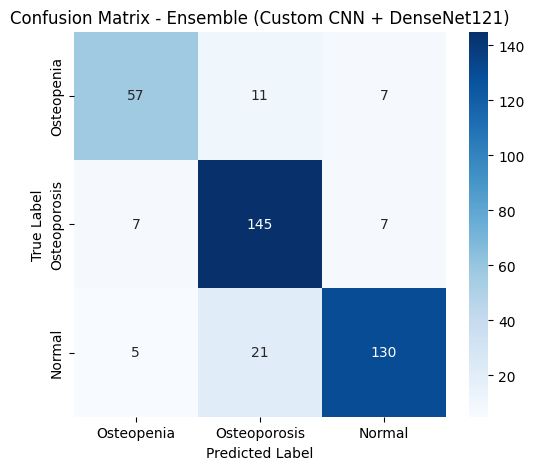

In [ ]:
# Ensemble: Custom CNN + DenseNet121

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("/kaggle/working/Osteoporosis.csv")
label_mapping = {label: idx for idx, label in enumerate(df['label'].unique())}
df['label'] = df['label'].map(label_mapping)

# Image loading
def load_image(image_path, target_size=(224, 224)):
    img = Image.open(image_path).convert('RGB').resize(target_size)
    img = img_to_array(img) / 255.0
    return img

image_paths = df['image'].values
labels = df['label'].values

train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42)

val_images = np.array([load_image(p) for p in val_paths])
val_labels_cat = tf.keras.utils.to_categorical(val_labels, num_classes=3)

# Data generator
def data_generator(image_paths, labels, batch_size=64):
    while True:
        for i in range(0, len(image_paths), batch_size):
            batch_paths = image_paths[i:i+batch_size]
            batch_labels = labels[i:i+batch_size]
            images = np.array([load_image(p) for p in batch_paths])
            yield images, tf.keras.utils.to_categorical(batch_labels, num_classes=3)

train_gen = data_generator(train_paths, train_labels)
val_gen = data_generator(val_paths, val_labels)

# Model: DenseNet121
base1 = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))
base1.trainable = False
x1 = GlobalAveragePooling2D()(base1.output)
x1 = Dense(128, activation='relu')(x1)
x1 = Dropout(0.5)(x1)
out1 = Dense(3, activation='softmax')(x1)
model1 = Model(inputs=base1.input, outputs=out1)
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model1.fit(train_gen, steps_per_epoch=len(train_paths)//64, epochs=100, 
           validation_data=val_gen, validation_steps=len(val_paths)//64,
           callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])

# Custom CNN
def create_custom_cnn():
    input_layer = Input(shape=(224, 224, 3))
    x = Conv2D(128, (8, 8), activation='relu', padding='same')(input_layer)
    x = Conv2D(256, (5, 5), activation='relu', padding='same')(x)
    x = MaxPooling2D((3, 3))(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(256, (1, 1), activation='relu', padding='same')(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Flatten()(x)
    output = Dense(3, activation='softmax')(x)
    return Model(inputs=input_layer, outputs=output)

model2 = create_custom_cnn()
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model2.fit(train_gen, steps_per_epoch=len(train_paths)//64, epochs=100, 
           validation_data=val_gen, validation_steps=len(val_paths)//64,
           callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])

# Ensemble predictions
preds1 = model1.predict(val_images)
preds2 = model2.predict(val_images)
ensemble_preds = (preds1 + preds2) / 2
final_preds = np.argmax(ensemble_preds, axis=1)

# Evaluation
print("Classification Report:")
print(classification_report(val_labels, final_preds, target_names=label_mapping.keys()))

cm = confusion_matrix(val_labels, final_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Ensemble (Custom CNN + DenseNet121)')
plt.show()